In [ ]:
#Install Libraries
!pip install yfinance beautifulsoup4

In [2]:
#Import Libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup

In [3]:
#Web Scraping (BeautifulSoup)
import pandas as pd
import requests
from bs4 import BeautifulSoup
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

table = soup.find("table")


df_table = pd.read_html(StringIO(str(table)))[0]

df_table.head()




,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [4]:
#Fetch Stock Data
df = yf.download("TSLA", start="2020-01-01", end="2024-01-01", auto_adjust=True)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [5]:
# Data Cleaning
df.reset_index(inplace=True)
df.dropna(inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

In [6]:
#Feature Engineering
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA100'] = df['Close'].rolling(window=100).mean()

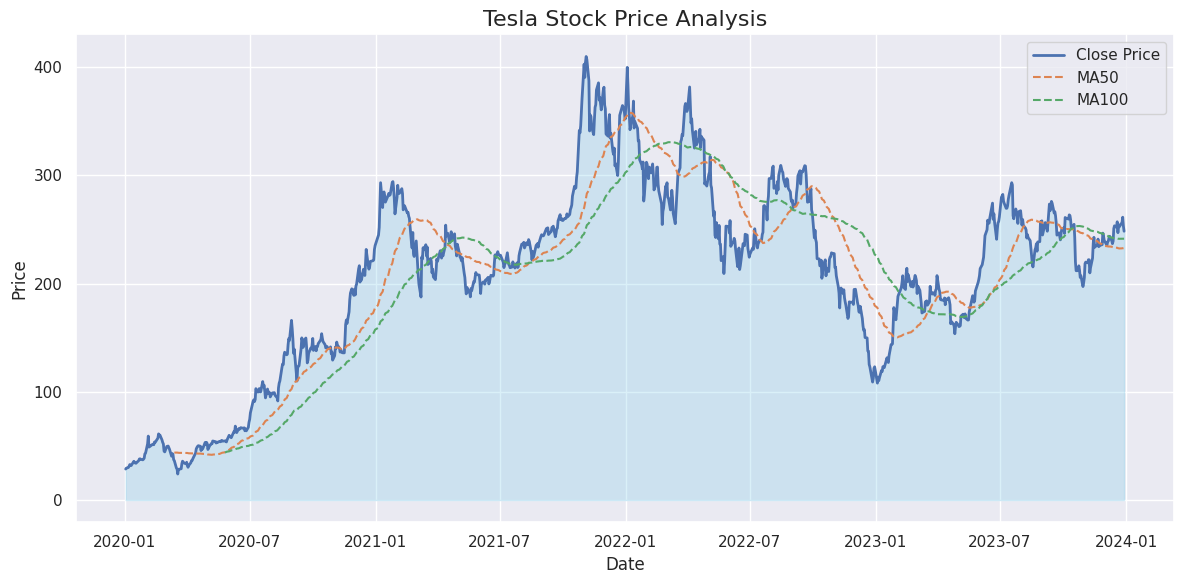

In [7]:
#Visualization (Matplotlib + Seaborn)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="darkgrid")


df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date'])


close = df['Close'].squeeze()
ma50 = df['MA50'].squeeze()
ma100 = df['MA100'].squeeze()

plt.figure(figsize=(12,6))

plt.plot(df['Date'], close, label='Close Price', linewidth=2)
plt.plot(df['Date'], ma50, label='MA50', linestyle='--')
plt.plot(df['Date'], ma100, label='MA100', linestyle='--')


plt.fill_between(df['Date'], close, color='skyblue', alpha=0.3)

plt.title("Tesla Stock Price Analysis", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
plt.savefig("stock_chart.png")

<Figure size 640x480 with 0 Axes>

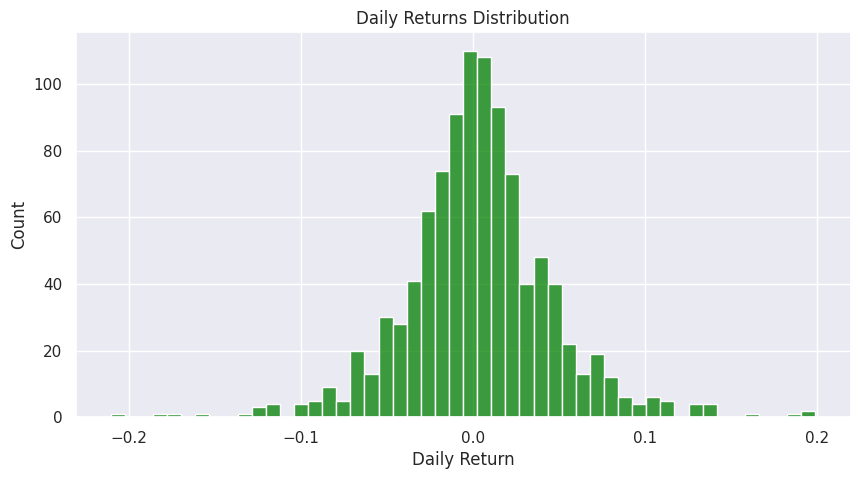

In [9]:
# ADD DAILY RETURNS
df['Daily Return'] = df['Close'].pct_change()

plt.figure(figsize=(10,5))
sns.histplot(df['Daily Return'].dropna(), bins=50, color='green')

plt.title("Daily Returns Distribution")
plt.show()

[*********************100%***********************]  3 of 3 completed


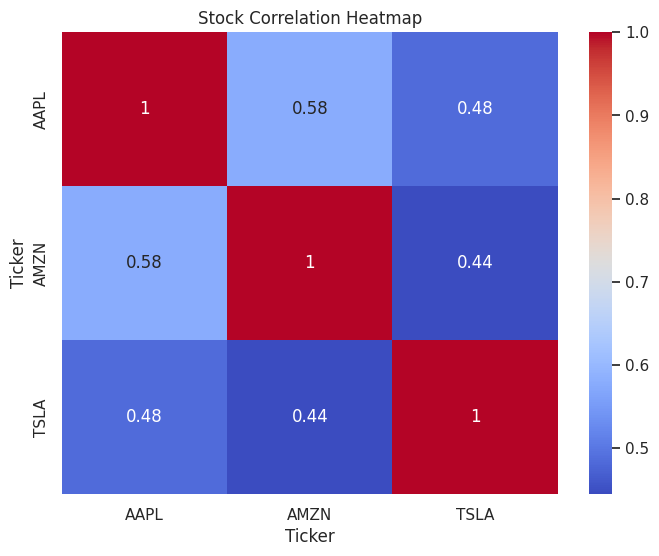

In [10]:
# Compare multiple stocks
# CORRELATION HEATMAP
stocks = ["TSLA", "AAPL", "AMZN"]

data = yf.download(stocks, start="2020-01-01", auto_adjust=True)['Close']
returns = data.pct_change()

plt.figure(figsize=(8,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")

plt.title("Stock Correlation Heatmap")
plt.show()

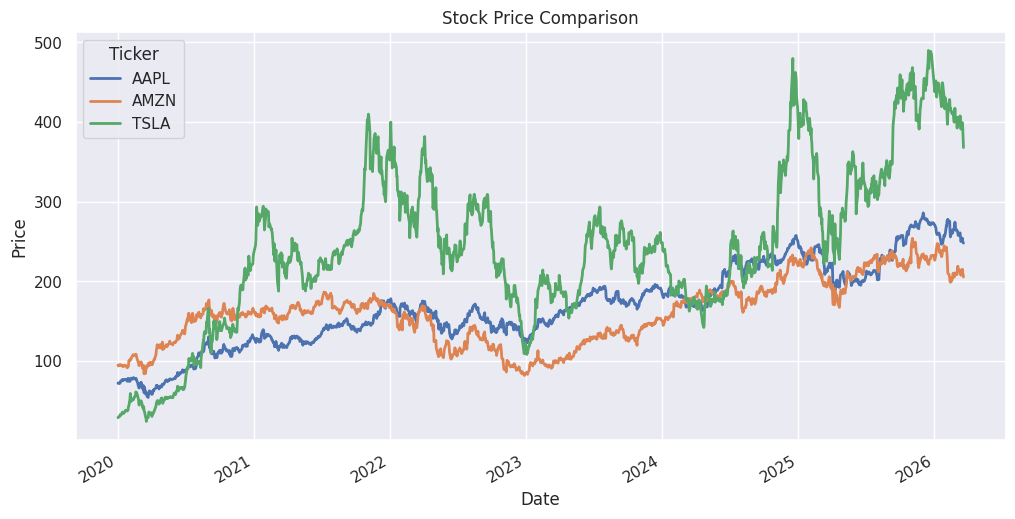

In [11]:
# MULTI-STOCK COMPARISON
data.plot(figsize=(12,6), linewidth=2)
plt.title("Stock Price Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

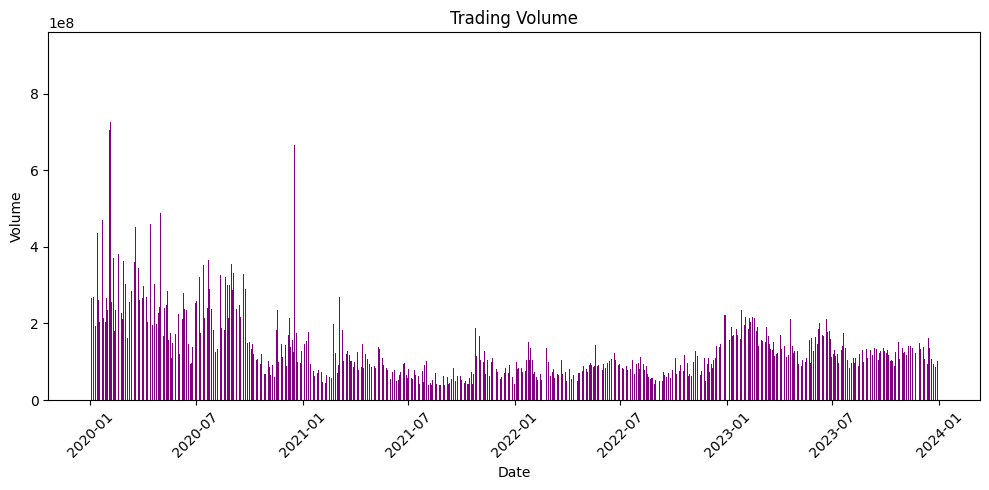

In [17]:
# VOLUME ANALYSIS
import matplotlib.pyplot as plt
import pandas as pd

# Reset index to get Date column
df = df.reset_index()

# Fix MultiIndex (if exists)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# Ensure Date format
df['Date'] = pd.to_datetime(df['Date'])

# Convert to 1D
volume = df['Volume'].squeeze()

# Use default style (no seaborn)
plt.style.use('default')

plt.figure(figsize=(10,5))

plt.bar(df['Date'], volume, color='purple')

plt.title("Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
!pip install mplfinance


/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


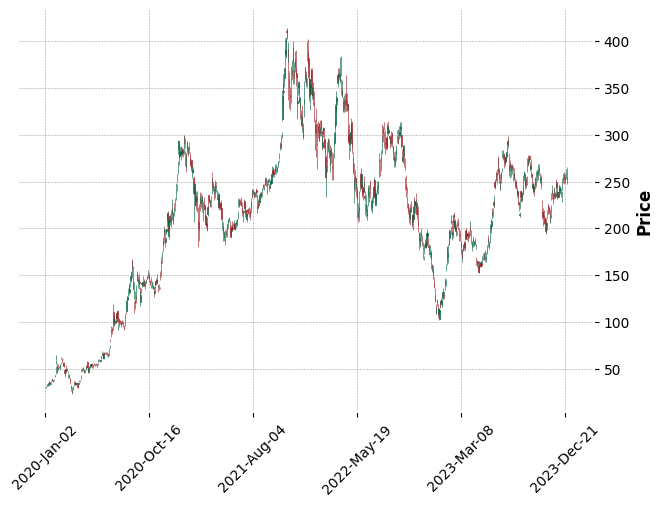

In [14]:
import mplfinance as mpf

df.set_index('Date', inplace=True)

mpf.plot(df, type='candle', style='charles')

In [15]:
# 📌 Insights
# 📊 Moving Average Insight

# Moving averages help smooth out price fluctuations and identify trends. When the stock price crosses above the moving average, it may indicate a bullish trend.

# 📉 Daily Return Insight

# Daily returns help measure volatility. Higher variation indicates higher risk and potential reward.

# 🔗 Correlation Insight

# Stocks with high correlation tend to move together, which is important for portfolio diversification.

In [16]:
# Conclusion
# This project demonstrates how raw financial data can be transformed into meaningful insights using Python.